In [13]:
%matplotlib inline

In [25]:
import logging

# qcodes imports
from qcodes.dataset import (
    Measurement,
    load_experiment_by_name,
    new_experiment,
    plot_by_id,
)
from qcodes.instrument_drivers.Keysight import KeysightN5245A

# setup
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)

# Start experiment
exp_name = "Cavity"
sample_name = "Thru_Coax"

try:
    exp = load_experiment_by_name(exp_name, sample = sample_name)
    print("Experiment loaded. Last ID no:", exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print("Starting new experiment.")

Experiment loaded. Last ID no: 3


In [50]:
pnd = KeysightN5245A("pnd", "USB0::0x2A8D::0x0001::MY55100528::INSTR")

Connected to: Keysight Technologies E5080A (serial:MY55100528, firmware:A.12.60.03) in 0.16s


In [62]:
import matplotlib.pyplot as plt
from qcodes.dataset import plot_dataset

Starting experimental run with id: 26. 


([<Axes: title={'center': 'Run #26, Experiment Cavity (Thru_Coax)'}, xlabel='Frequency (GHz)', ylabel='Magnitude (dB)'>],
 [None])

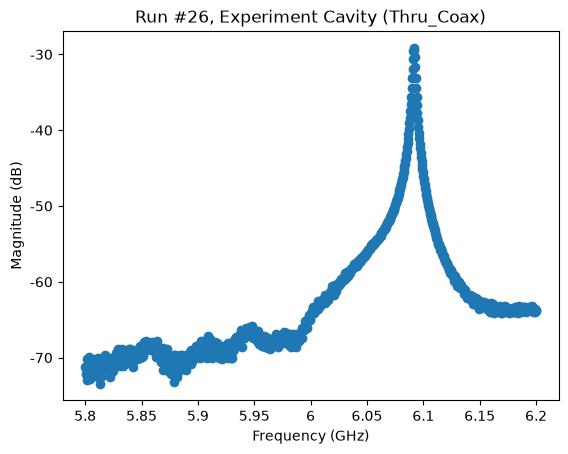

In [60]:
# Set up a frequency sweep from 100 MHz to 1 GHz, with 1001 points, at a power of -40dBm
pnd.power(-30)
pnd.start(5.8e9)
pnd.stop(6.2e9)
pnd.points(1001)
pnd.trace("S21")

# Enable 2 averages, and set IF BW to 1kHz
pnd.if_bandwidth(1e3)
pnd.averages_enabled(True)
pnd.averages(10)

# Run a measurement
meas = Measurement()
meas.register_parameter(pnd.magnitude)

with meas.run() as datasaver:
    mag = pnd.magnitude()
    datasaver.add_result((pnd.magnitude, mag))
    dataid = datasaver.run_id
plot_by_id(dataid)

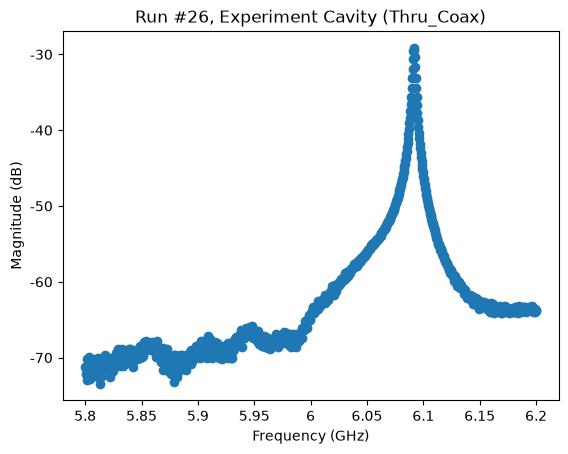

In [64]:
axes, colorbars = plot_by_id(dataid)
fig = axes[0].figure
fig.savefig(f"qcodes_cavity_expirement.png")

In [ ]:
def S_21(f, Ql, Qc, fr):
    f_mhz = f / 1e6
    fr_mhz = fr / 1e6
    top = Ql/Qc
    bottom = 1+ 2j * Ql * (f_mhz/fr_mhz -1)
    return (1 - top/bottom)

def convert_S21_to_dB(f,Ql,Qc,fr):
    S = S_21(f,Ql,Qc,fr)
    linear = np.abs(S)
    return 20 * np.log10(linear)

def Real(f,Ql,Qc,fr):
    R = 2j *Ql * (f/fr - 1)
    return (-R**2 - Ql/Qc + 1)/(1-R**2)

def Complex(f,Ql,Qc,fr):
    R = 2j *Ql * (f/fr - 1)
    return (2j * Ql**2/Qc * (f/fr - 1))/(1-R**2)



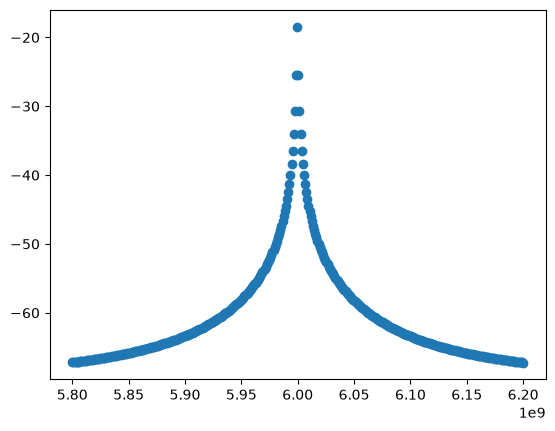

In [210]:
def S_21_other(f, Ql, Qc, fr):
    f_mhz = f / 1e6
    fr_mhz = fr / 1e6
    top = Ql/Qc
    bottom = 1+ 2j * Ql * (f_mhz/fr_mhz -1)
    return np.abs(top/bottom)

def convert_S21_to_dB(f,Ql,Qc,fr,baseline_dB):
    S = S_21(f,Ql,Qc,fr)
    linear = np.abs(S)
    baseline_linear = 10**(baseline_dB/20)
    total_linear = np.sqrt(linear**2 + baseline_linear**2)
    return 20 * np.log10(total_linear)


def convert_S21_other_to_dB(f,Ql,Qc,fr,baseline_dB):
    S = S_21_other(f,Ql,Qc,fr)
    baseline_linear = 10 ** (baseline_dB / 20)
    total_linear = np.sqrt(S**2 + baseline_linear**2)
    converted =  20 * np.log10(total_linear)
    return converted

# print((S_21(1***4,6*10**3,5*10**4,6*10**4)))
# print(S_21_other(1*10**4,6*10**3,5*10**4,6*10**4))

#print(convert_S21_to_dB(1*10**4,6*10**3,5*10**4,6*10**4,-70))
#print(convert_S21_other_to_dB(1*10**4,6*10**3,5*10**4,6*10**4,-70))
# #S_21_other(5*10**4,6*10**3,5*10**4,6*10**4)
a = []
for i in np.arange(5.8,6.2+0.001,0.001):
    a.append(convert_S21_other_to_dB(i*10**4,6*10**3,5*10**4,6*10**4,-70))
plt.scatter(np.linspace(5.8e9, 6.2e9, len(a)),a)

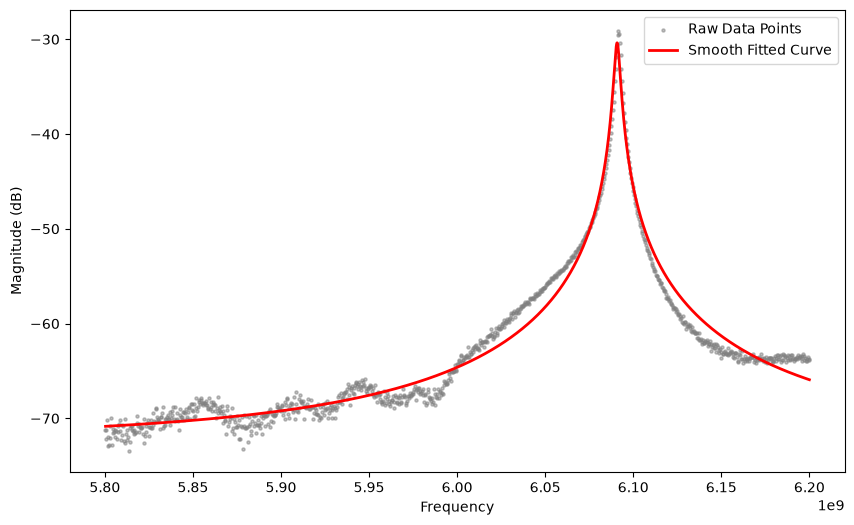

In [179]:
from scipy.optimize import curve_fit
#range from 5.8 to 6.2 GHz with 1001 points
x_data = np.linspace(5.8e9, 6.2e9, 1001)
y_data = np.array(mag[:1001])

guess_Ql = 20*10**3.0
guess_Qc = 5*10**4.0
peak_index = np.argmax(y_data)  
guess_fr = x_data[peak_index]
guess_baseline = -70
p0_guesses = [guess_Ql, guess_Qc, guess_fr, guess_baseline] 

popt, _ = curve_fit(convert_S21_other_to_dB, x_data, y_data, p0=p0_guesses)
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline = popt

x_curve = np.linspace(x_data[1], x_data[-1], 5000)
y_curve = convert_S21_other_to_dB(x_curve, optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline)


plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
plt.xlabel('Frequency')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.show()

In [203]:
popt

array([ 1.88092869e+03,  6.21027197e+04,  6.09083153e+09, -7.26905975e+01])